In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
files.upload()
books_df = pd.read_csv("books_dataset.csv")
books_df.head()

Saving books_dataset.csv to books_dataset.csv


,book_id,title,author,genre,publication_year,page_count,rating_out_of_5,ratings_count_thousands,price_usd
0,101,To Kill a Mockingbird,Harper Lee,Classic Fiction,1960.0,281.0,4.27,5600.0,8.99
1,102,1984,George Orwell,Dystopian,1949.0,328.0,4.19,4400.0,9.99
2,103,The Great Gatsby,F. Scott Fitzgerald,Classic Fiction,1925.0,180.0,3.93,4800.0,10.99
3,104,The Hobbit,J.R.R. Tolkien,Fantasy,1937.0,310.0,4.28,3700.0,12.50
4,105,Dune,Frank Herbert,Sci-Fi,1965.0,688.0,4.25,1300.0,14.99


In [ ]:
books_df.isnull().sum()

,0
book_id,0
title,0
author,0
genre,1
publication_year,1
page_count,1
rating_out_of_5,1
ratings_count_thousands,1
price_usd,1


In [ ]:
books_df['page_count']=books_df['page_count'].fillna(books_df['page_count'].mean())
books_df['rating_out_of_5']=books_df['rating_out_of_5'].fillna(books_df['rating_out_of_5'].mean())
books_df['ratings_count_thousands']=books_df['ratings_count_thousands'].fillna(books_df['ratings_count_thousands'].mean())
books_df['price_usd']=books_df['price_usd'].fillna(books_df['price_usd'].mean())
books_df.isnull().sum()

,0
book_id,0
title,0
author,0
genre,1
publication_year,1
page_count,0
rating_out_of_5,0
ratings_count_thousands,0
price_usd,0


In [ ]:
books_df.dropna(subset=['genre','publication_year'],inplace=True)
books_df.isnull().sum()

,0
book_id,0
title,0
author,0
genre,0
publication_year,0
page_count,0
rating_out_of_5,0
ratings_count_thousands,0
price_usd,0


In [ ]:
genre_avg_price = books_df.groupby('genre')['price_usd'].mean()
print("---Average Book Price by Genre---")
print(genre_avg_price)
top_reads = books_df[books_df['rating_out_of_5'] >= 4.25]
print("\n---Top Reads (Rating >=4.25)---")
top_reads[['title','rating_out_of_5','genre']]

---Average Book Price by Genre---
genre
Classic Fiction        9.323333
Dystopian              9.060000
Fantasy               13.750000
Historical Fiction     9.500000
Sci-Fi                12.120238
Name: price_usd, dtype: float64

---Top Reads (Rating >=4.25)---


,title,rating_out_of_5,genre
0,To Kill a Mockingbird,4.27,Classic Fiction
3,The Hobbit,4.28,Fantasy
4,Dune,4.25,Sci-Fi
8,The Fellowship of the Ring,4.38,Fantasy
11,The Book Thief,4.39,Historical Fiction
13,Ender's Game,4.30,Sci-Fi
14,The Martian,4.40,Sci-Fi


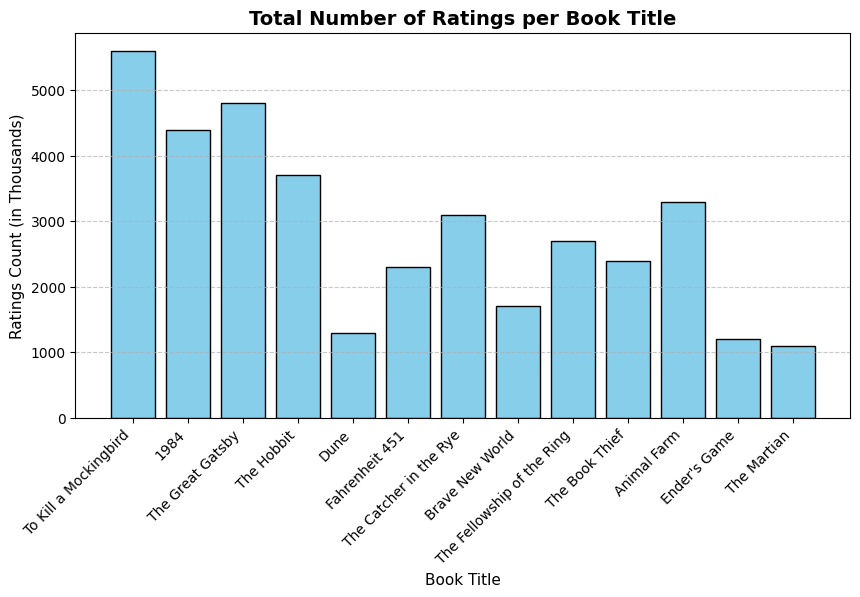

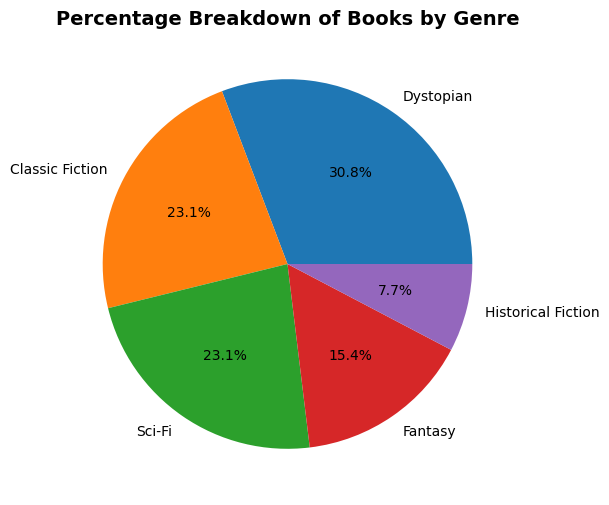

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(books_df['title'],books_df['ratings_count_thousands'],color='skyblue',edgecolor='black')
plt.title("Total Number of Ratings per Book Title",fontsize=14,fontweight='bold')
plt.xlabel("Book Title",fontsize=11)
plt.ylabel("Ratings Count (in Thousands)",fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

genre_counts = books_df['genre'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(genre_counts,labels=genre_counts.index,autopct='%1.1f%%')
plt.title("Percentage Breakdown of Books by Genre",fontsize=14,fontweight='bold')
plt.show()